# 1. 데이터 전처리

사용 데이터셋

서울시 주민등록인구(내국인, 세별, 구별)
https://data.seoul.go.kr/dataList/10719/S/2/datasetView.do

서울시 일반음식점 인허가 정보
https://data.seoul.go.kr/dataList/OA-16094/S/1/datasetView.do

서울시 약국 인허가 정보
https://data.seoul.go.kr/dataList/OA-16484/S/1/datasetView.do

서울시 병의원 위치 정보
https://data.seoul.go.kr/dataList/OA-20337/S/1/datasetView.do

서울시 안정상비의약품 판매업소 인허가 정보
https://data.seoul.go.kr/dataList/OA-16483/S/1/datasetView.do


서울시 시가화면적 통계- * 시가화면적 : 용도지역 중 주거지역, 상업지역 및 공업지역 면적의 합
https://data.seoul.go.kr/dataList/569/S/2/datasetView.do

서울시 자치구별 지하철역
https://data.seoul.go.kr/dataList/OA-22493/L/1/datasetView.do




In [1]:
import pandas as pd
import geopandas as gpd
import os
import json
import folium
import re
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from scipy.stats import pearsonr

# 폴더 경로
DATA_DIR = "data"

# 파일 목록 확인
print("data 폴더:", os.listdir(DATA_DIR))

data 폴더: ['.ipynb_checkpoints', '구별_버스.xlsx', '구별_지하철.csv', '서울시 병의원 위치 정보.csv', '서울시 약국 인허가 정보.csv', '서울시 일반음식점 인허가 정보.csv', '서울시_상비약품판매업소.csv', '서울시_인구_구별.csv', '시가화면적 .csv']


In [2]:
#파일들 인코딩

csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".csv")]
csv_files

for file in csv_files:
    path = os.path.join(DATA_DIR, file)
    print("=" * 80)
    print(file)
    
    try:
        df = pd.read_csv(path, encoding="utf-8")
    except UnicodeDecodeError:
        df = pd.read_csv(path, encoding="cp949")
    
    print("shape:", df.shape)
    print("columns:", df.columns.tolist())
    display(df.head())


구별_지하철.csv
shape: (30, 3)
columns: ['자치구', '해당역(호선)', '역개수']


,자치구,해당역(호선),역개수
0,강남구,"삼성(2), 선릉(2), 역삼(2), 강남(2), 압구정(3), 신사(3), 매봉(...",21
1,강동구,"천호(5), 강동(5), 길동(5), 굽은다리(5), 명일(5), 고덕(5), 상일...",15
2,강북구,"수유(4), 미아(4), 미아사거리(4)",3
3,강서구,"방화(5), 개화산(5), 김포공항(5), 송정(5), 마곡(5), 발산(5), 우...",9
4,관악구,"낙성대(2), 서울대입구(2), 봉천(2), 신림(2)",4


서울시 병의원 위치 정보.csv
shape: (22239, 34)
columns: ['기관ID', '주소', '병원분류', '병원분류명', '응급의료기관코드', '응급의료기관코드명', '응급실운영여부(1/2)', '비고', '기관설명상세', '간이약도', '기관명', '대표전화1', '응급실전화', '진료시간(월요일)C', '진료시간(화요일)C', '진료시간(수요일)C', '진료시간(목요일)C', '진료시간(금요일)C', '진료시간(토요일)C', '진료시간(일요일)C', '진료시간(공휴일)C', '진료시간(월요일)S', '진료시간(화요일)S', '진료시간(수요일)S', '진료시간(목요일)S', '진료시간(금요일)S', '진료시간(토요일)S', '진료시간(일요일)S', '진료시간(공휴일)S', '우편번호1', '우편번호2', '병원경도', '병원위도', '작업시간']


,기관ID,주소,병원분류,병원분류명,응급의료기관코드,응급의료기관코드명,응급실운영여부(1/2),비고,기관설명상세,간이약도,...,진료시간(목요일)S,진료시간(금요일)S,진료시간(토요일)S,진료시간(일요일)S,진료시간(공휴일)S,우편번호1,우편번호2,병원경도,병원위도,작업시간
0,A1120837,"서울특별시 금천구 벚꽃로 286, 삼성리더스타워 111~114호 (가산동)",C,의원,G099,응급의료기관 이외,2,"외과: 상시진료, 내과는 당분간 휴진","서울시 송파구 문정동 장지동 법조단지 위례 가락동 가락시장역 위치, 삼성서울병원 외...",방이역 1번출구 바로옆 굿모닝 신한증권 뒷건물,...,900,900,900.0,1000.0,1000.0,85,11,126.884122,37.480394,2022-04-07 14:55:00.0
1,A1104130,"서울특별시 강남구 도산대로 118 (논현동, 신사빌딩 2층)",C,의원,G099,응급의료기관 이외,2,비만클리닉,"365일 진료, 국민건강보험공단 검진 지정병원 점심시간 13~14시",신사역 1번 출구 인근,...,1100,1100,1100.0,900.0,900.0,60,38,127.021809,37.516604,2021-06-07 14:54:49.0
2,A1121126,"서울특별시 양천구 목동동로 293, 현대41타워 406,407호 (목동)",C,의원,G099,응급의료기관 이외,2,점심시간 13:00~14:00 접수는 마감 30분 전까지,안녕하세요 마디로한의원 송파거여점입니다. 5호선 거여역 7번 출구 바로 앞에 위치해...,강동역 2-1번 출구,...,900,900,900.0,900.0,900.0,79,97,126.875772,37.528178,2026-04-07 14:53:26.0
3,A1116728,"서울특별시 양천구 목동동로 293, 현대41타워 504,505호 (목동)",C,의원,G099,응급의료기관 이외,2,"토요일 : 예약환자[수술,드림렌즈]만 진료",안녕하세요 마디로한의원 송파거여점입니다. 5호선 거여역 7번 출구 바로 앞에 위치해...,CBS기독교방송 옆 건물,...,930,930,930.0,900.0,900.0,79,97,126.875772,37.528178,2026-04-07 14:53:26.0
4,A1117873,"서울특별시 관악구 신원로 38, 5층 (신림동, 청암빌딩)",N,치과의원,G099,응급의료기관 이외,2,대표번호1 지역번호 추가20170118150453,"서울시 송파구 문정동 장지동 법조단지 위례 가락동 가락시장역 위치, 삼성서울병원 외...",서월치안센터 인근 청암빌딩 5층,...,1400,1000,1000.0,1000.0,1000.0,87,76,126.929377,37.481918,2022-01-07 14:54:55.0


서울시 약국 인허가 정보.csv
shape: (5876, 24)
columns: ['개방자치단체코드', '관리번호', '인허가일자', '인허가취소일자', '영업상태코드', '영업상태명', '상세영업상태코드', '상세영업상태명', '폐업일자', '휴업시작일자', '휴업종료일자', '전화번호', '소재지우편번호', '지번주소', '도로명주소', '도로명우편번호', '사업장명', '최종수정일자', '데이터갱신구분', '데이터갱신일자', '좌표정보(X)', '좌표정보(Y)', '약국영업면적', '지정일자']


...

,개방자치단체코드,관리번호,인허가일자,인허가취소일자,영업상태코드,영업상태명,상세영업상태코드,상세영업상태명,폐업일자,휴업시작일자,...,지번주소,도로명주소,도로명우편번호,사업장명,최종수정일자,데이터갱신구분,데이터갱신일자,좌표정보(X),좌표정보(Y),판매점영업면적
0,3110000,PHMH320243110032087500027,2024-09-12,,1,영업/정상,13,영업중,,,...,서울특별시 은평구 응암동 119-29 마이유아파트,"서울특별시 은평구 응암로21가길 20, 102~104호 (응암동, 마이유아파트)",03455,씨유응암본점,2024-09-12 16:32:16,I,2026-04-29 23:03:39,192676.151253818,454770.723478469,88.0
1,3110000,PHMH320243110032087500029,2024-10-31,,1,영업/정상,13,영업중,,,...,NaN,서울특별시 은평구 통일로65길 12-8 (대조동),03397,씨유불광NC점,2024-10-31 16:10:47,I,2026-04-29 23:03:39,193723.1564212,456369.530117768,NaN
2,3000000,PHMH320123000034087500062,2012-11-12,,3,폐업,3,폐업,2015-07-03,,...,NaN,"서울특별시 종로구 삼봉로 100, 1층 (공평동)",,씨유 종로공평점,2015-07-03 15:06:35,I,2026-04-29 23:03:21,198403.062908229,452180.670203793,NaN
3,3210000,PHMH320123210034087500024,2012-11-13,,3,폐업,3,폐업,2013-09-27,,...,서울특별시 서초구 서초동 1364번지 11호,서울특별시 서초구 서운로 6 (서초동),,지에스25서초코날점,2013-09-27 17:36:28,I,2026-03-26 22:32:07,202580.12152321,442504.857274177,NaN
4,3210000,PHMH320193210034087500002,2019-01-02,,3,폐업,3,폐업,2025-03-14,,...,서울특별시 서초구 방배동 778번지 30호 1층,"서울특별시 서초구 방배중앙로21길 10, 1층 (방배동)",06558,세븐일레븐방배중앙로점,2025-03-14 14:40:42,I,2026-03-26 22:32:21,198692.865865338,443379.492827847,90.0


서울시_인구_구별.csv
shape: (79, 104)
columns: ['자치구별(1)', '성별(1)', '2026 1/4', '2026 1/4.1', '2026 1/4.2', '2026 1/4.3', '2026 1/4.4', '2026 1/4.5', '2026 1/4.6', '2026 1/4.7', '2026 1/4.8', '2026 1/4.9', '2026 1/4.10', '2026 1/4.11', '2026 1/4.12', '2026 1/4.13', '2026 1/4.14', '2026 1/4.15', '2026 1/4.16', '2026 1/4.17', '2026 1/4.18', '2026 1/4.19', '2026 1/4.20', '2026 1/4.21', '2026 1/4.22', '2026 1/4.23', '2026 1/4.24', '2026 1/4.25', '2026 1/4.26', '2026 1/4.27', '2026 1/4.28', '2026 1/4.29', '2026 1/4.30', '2026 1/4.31', '2026 1/4.32', '2026 1/4.33', '2026 1/4.34', '2026 1/4.35', '2026 1/4.36', '2026 1/4.37', '2026 1/4.38', '2026 1/4.39', '2026 1/4.40', '2026 1/4.41', '2026 1/4.42', '2026 1/4.43', '2026 1/4.44', '2026 1/4.45', '2026 1/4.46', '2026 1/4.47', '2026 1/4.48', '2026 1/4.49', '2026 1/4.50', '2026 1/4.51', '2026 1/4.52', '2026 1/4.53', '2026 1/4.54', '2026 1/4.55', '2026 1/4.56', '2026 1/4.57', '2026 1/4.58', '2026 1/4.59', '2026 1/4.60', '2026 1/4.61', '2026 1/4.62', '2026 

,자치구별(1),성별(1),2026 1/4,2026 1/4.1,2026 1/4.2,2026 1/4.3,2026 1/4.4,2026 1/4.5,2026 1/4.6,2026 1/4.7,...,2026 1/4.92,2026 1/4.93,2026 1/4.94,2026 1/4.95,2026 1/4.96,2026 1/4.97,2026 1/4.98,2026 1/4.99,2026 1/4.100,2026 1/4.101
0,자치구별(1),성별(1),합계,0세,1세,2세,3세,4세,5세,6세,...,91세,92세,93세,94세,95세,96세,97세,98세,99세,100세 이상+
1,합계,합계,9304400,45335,40897,36748,39352,41836,42813,46163,...,11683,8680,6615,4874,3488,2759,2058,1410,893,1459
2,합계,남자,4480938,23270,20908,18913,19943,21567,21937,23984,...,3579,2499,1843,1217,832,635,495,300,166,311
3,합계,여자,4823462,22065,19989,17835,19409,20269,20876,22179,...,8104,6181,4772,3657,2656,2124,1563,1110,727,1148
4,종로구,합계,136817,446,446,408,418,474,481,534,...,257,197,152,109,81,51,52,25,30,35


시가화면적 .csv
shape: (78, 5)
columns: ['자치구별(1)', '자치구별(2)', '시가화면적별(1)', '시가화면적별(2)', '2019']


,자치구별(1),자치구별(2),시가화면적별(1),시가화면적별(2),2019
0,서울시,소계,행정구역면적 (㎢),소계,605.24
1,서울시,소계,시가화면적 현황,시가화면적 (㎢),371.54
2,서울시,소계,시가화면적 현황,시가화면적비율 (%),61.39
3,서울시,종로구,행정구역면적 (㎢),소계,23.91
4,서울시,종로구,시가화면적 현황,시가화면적 (㎢),12.77


In [3]:
#서울시 인구_ 구별 csv 파일에서 구별 인구 추출

df_pop_raw = pd.read_csv(
    "data/서울시_인구_구별.csv",
    encoding="utf-8-sig",
    header=1
)

df_pop_raw.columns = df_pop_raw.columns.str.strip()


# 필요한 컬럼만 사용
df_pop = df_pop_raw[['자치구별(1)', '성별(1)', '합계']]

df_pop = df_pop[df_pop['성별(1)'] == '합계']
df_pop = df_pop[df_pop['자치구별(1)'] != '합계']

df_pop = df_pop[['자치구별(1)', '합계']]
df_pop.columns = ['구', '인구']

df_pop['인구'] = df_pop['인구'].astype(int)


df_age = df_pop_raw[
    (df_pop_raw['성별(1)'] == '합계') &
    (df_pop_raw['자치구별(1)'] != '합계')
].copy()


# 확인
print(df_pop.shape)
display(df_pop.head())
print(df_pop['구'].tolist())

(25, 2)


,구,인구
3,종로구,136817
6,중구,117762
9,용산구,200962
12,성동구,275093
15,광진구,331123


['종로구', '중구', '용산구', '성동구', '광진구', '동대문구', '중랑구', '성북구', '강북구', '도봉구', '노원구', '은평구', '서대문구', '마포구', '양천구', '강서구', '구로구', '금천구', '영등포구', '동작구', '관악구', '서초구', '강남구', '송파구', '강동구']


In [4]:
# 서울 인구수 확인-> 성공

# 구별 인구 합계
total_pop = df_pop['인구'].sum()
print("구별 인구 합계:", total_pop)


# 원본 데이터에서 '서울 전체 합계' 추출
df_raw = pd.read_csv(
    "data/서울시_인구_구별.csv",
    encoding="utf-8-sig",
    header=1
)

df_raw.columns = df_raw.columns.str.strip()

seoul_total = df_raw[
    (df_raw['자치구별(1)'] == '합계') &
    (df_raw['성별(1)'] == '합계')
]['합계'].values[0]

print("서울 전체 인구:", seoul_total)


# 비교
print("일치 여부:", total_pop == seoul_total)

구별 인구 합계: 9304400
서울 전체 인구: 9304400
일치 여부: True


In [5]:
# CSV 자동 읽기 함수
def read_csv_auto(path, low_memory=True):
    encodings = ["utf-8-sig", "utf-8", "cp949", "euc-kr"]
    
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc, low_memory=low_memory)
        except UnicodeDecodeError:
            continue
    
    raise UnicodeDecodeError("encoding", b"", 0, 1, f"Cannot decode file: {path}")


# 주소에서 구 추출
def extract_gu(address):
    if pd.isna(address):
        return None
    
    address = str(address)
    match = re.search(r"서울특별시\s+(\S+구)", address)
    
    return match.group(1) if match else None


# 병원 -> 추출 성공
hospital = read_csv_auto("data/서울시 병의원 위치 정보.csv")
hospital["구"] = hospital["주소"].apply(extract_gu)
hospital_gu = hospital.groupby("구").size().reset_index(name="병원수")


# 약국 -> 도로명 주소 없는 데이터 1개 제외하고 추출 성공
pharmacy_raw = read_csv_auto("data/서울시 약국 인허가 정보.csv")
pharmacy = pharmacy_raw[pharmacy_raw["영업상태명"] == "영업/정상"].copy()
pharmacy["구"] = pharmacy["도로명주소"].apply(extract_gu)
pharmacy = pharmacy.dropna(subset=["구"])
pharmacy_gu = pharmacy.groupby("구").size().reset_index(name="약국수")


# 음식점
restaurant = read_csv_auto("data/서울시 일반음식점 인허가 정보.csv", low_memory=False)
restaurant = restaurant[restaurant["영업상태명"] == "영업/정상"]
restaurant["구"] = restaurant["도로명주소"].apply(extract_gu)
restaurant_gu = restaurant.groupby("구").size().reset_index(name="음식점수")


# 상비약 판매업소
medicine_store_raw = read_csv_auto("data/서울시_상비약품판매업소.csv")
medicine_store = medicine_store_raw[ medicine_store_raw["영업상태명"] == "영업/정상"
].copy()
medicine_store["구"] = medicine_store["도로명주소"].apply(extract_gu)
medicine_store = medicine_store.dropna(subset=["구"])
medicine_store_gu = medicine_store.groupby("구").size().reset_index(name="상비약판매업소수")



#시가화면적 
area = read_csv_auto("data/시가화면적 .csv")

area.columns = area.columns.str.strip()
area = area[area["시가화면적별(2)"] == "시가화면적 (㎢)"].copy()
area = area[area["자치구별(2)"] != "소계"]
area_gu = area[["자치구별(2)", "2019"]].copy()
area_gu.columns = ["구", "시가화면적"]
area_gu["시가화면적"] = pd.to_numeric(area_gu["시가화면적"], errors="coerce")



# 지하철 데이터 전처리- 서울시 아닌게 5개 더 들어가있어서 제거

seoul_gu_list = df_pop["구"].tolist()
subway = read_csv_auto("data/구별_지하철.CSV")
subway.columns = subway.columns.str.strip()
subway_gu = subway[["자치구", "역개수"]].copy()
subway_gu.columns = ["구", "역수"]
subway_gu["역수"] = pd.to_numeric(subway_gu["역수"], errors="coerce")

# 서울시 25개 자치구만 필터링
subway_gu = subway_gu[subway_gu["구"].isin(seoul_gu_list)].copy()


# 결과 확인
display(hospital_gu.head())
display(pharmacy_gu.head())
display(restaurant_gu.head())
display(medicine_store_gu.head())
display(area_gu.head())
display(subway_gu.head())


print("병원 구 개수:", hospital_gu.shape)
print("약국 구 개수:", pharmacy_gu.shape)
print("음식점 구 개수:", restaurant_gu.shape)
print("상비약 판매업소 구 개수:", medicine_store_gu.shape)
print("시가화면적 구 개수:", area_gu.shape)
print("지하철 구 개수:", subway_gu.shape)



,구,병원수
0,강남구,3644
1,강동구,1060
2,강북구,533
3,강서구,1087
4,관악구,797


,구,약국수
0,강남구,563
1,강동구,308
2,강북구,167
3,강서구,292
4,관악구,240


,구,음식점수
0,강남구,12228
1,강동구,3958
2,강북구,3247
3,강서구,5481
4,관악구,4705


,구,상비약판매업소수
0,강남구,650
1,강동구,292
2,강북구,209
3,강서구,375
4,관악구,363


,구,시가화면적
4,종로구,12.77
7,중구,9.95
10,용산구,13.37
13,성동구,12.47
16,광진구,11.80


,구,역수
0,강남구,21
1,강동구,15
2,강북구,3
3,강서구,9
4,관악구,4


병원 구 개수: (25, 2)
약국 구 개수: (25, 2)
음식점 구 개수: (25, 2)
상비약 판매업소 구 개수: (25, 2)
시가화면적 구 개수: (25, 2)
지하철 구 개수: (25, 2)


In [6]:
!pip install openpyxl


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
#구별_버스.xlsx 인코딩 및 데이터 불러오기

bus = pd.read_excel("data/구별_버스.xlsx")

# 컬럼명 공백 제거
bus.columns = bus.columns.str.strip()

# 자치구별 버스정류장 수 집계
bus_gu = (
    bus.groupby("자치구")
    .size()
    .reset_index(name="버스정류장수")
)

# 컬럼명 통일
bus_gu.columns = ["구", "버스정류장수"]

# 서울시 25개 자치구만 필터링
bus_gu = bus_gu[bus_gu["구"].isin(seoul_gu_list)].copy()

display(bus_gu)
print("버스정류장 구 개수:", bus_gu.shape)

,구,버스정류장수
0,강남구,430
1,강동구,313
2,강북구,195
3,강서구,338
4,관악구,259
5,광진구,174
6,구로구,255
7,금천구,170
8,노원구,392
9,도봉구,232


버스정류장 구 개수: (25, 2)


## 2. 데이터셋 올바르게 나눠졌는지 검증

In [8]:
#데이터셋 구별 올바르게 나눠졌는지 검증


# 1. 원본 로드
df_pop_raw = pd.read_csv(
    "data/서울시_인구_구별.csv",
    encoding="utf-8-sig",
    header=1
)

df_pop_raw.columns = df_pop_raw.columns.str.strip()

# =========================
# 2. 총인구 (기존 코드 유지)
# =========================
df_pop = df_pop_raw[
    (df_pop_raw['성별(1)'] == '합계') &
    (df_pop_raw['자치구별(1)'] != '합계')
][['자치구별(1)', '합계']].copy()

df_pop.columns = ['구', '인구']
df_pop['인구'] = df_pop['인구'].astype(int)

# =========================
# 3. 연령 데이터 생성
# =========================
df_age = df_pop_raw[
    (df_pop_raw['성별(1)'] == '합계') &
    (df_pop_raw['자치구별(1)'] != '합계')
].copy()

# 연령 컬럼 추출 (0세 ~ 끝)
age_cols = [col for col in df_age.columns if col.endswith('세')]

# 고령 (65세 이상)
elderly_cols = [col for col in age_cols if int(col.replace('세','')) >= 65]

# 청년 (15~64)
young_cols = [col for col in age_cols if 15 <= int(col.replace('세','')) < 65]

# 계산
df_age['고령인구'] = df_age[elderly_cols].sum(axis=1)
df_age['청년인구'] = df_age[young_cols].sum(axis=1)

df_age['고령화율'] = df_age['고령인구'] / df_age['합계']
df_age['청년비율'] = df_age['청년인구'] / df_age['합계']

# 필요한 컬럼만 정리
df_age = df_age[['자치구별(1)', '고령화율', '청년비율']]
df_age.columns = ['구', '고령화율', '청년비율']

# =========================
# 4. 성별 데이터
# =========================
df_gender = df_pop_raw[
    (df_pop_raw['자치구별(1)'] != '합계') &
    (df_pop_raw['성별(1)'].isin(['남자', '여자']))
][['자치구별(1)', '성별(1)', '합계']]

df_gender = df_gender.pivot(
    index='자치구별(1)',
    columns='성별(1)',
    values='합계'
)

# 성비
df_gender['성비'] = df_gender['남자'] / df_gender['여자']

df_gender = df_gender[['성비']]
df_gender.index.name = '구'
df_gender = df_gender.reset_index()

# =========================
# 5. 최종 결합
# =========================
df_pop = df_pop.merge(df_age, on='구')
df_pop = df_pop.merge(df_gender, on='구')

# =========================
# 6. 확인
# =========================
print(df_pop.shape)
display(df_pop.head)
print('제대로 안들어간거: ', df_pop.isna().sum())
print('구 개수: ', df_pop['구'].nunique())


(25, 5)


<bound method NDFrame.head of        구      인구      고령화율      청년비율        성비
0    종로구  136817  0.226653  0.706535  0.918435
1     중구  117762  0.233310  0.702502  0.924373
2    용산구  200962  0.199889  0.721211  0.906262
3    성동구  275093  0.196214  0.717339  0.931412
4    광진구  331123  0.190841  0.736316  0.917619
5   동대문구  351542  0.209682  0.708942  0.949729
6    중랑구  376665  0.237521  0.689931  0.952998
7    성북구  422778  0.208954  0.703620  0.913187
8    강북구  278786  0.269572  0.667734  0.924746
9    도봉구  299065  0.265374  0.662953  0.930859
10   노원구  482487  0.219726  0.691666  0.916547
11   은평구  454109  0.228273  0.693448  0.896166
12  서대문구  300594  0.208767  0.706711  0.892314
13   마포구  356966  0.174695  0.740409  0.865806
14   양천구  423666  0.202169  0.690591  0.947352
15   강서구  548985  0.209157  0.707493  0.913326
16   구로구  382836  0.227494  0.688783  0.954861
17   금천구  222712  0.226162  0.712274  1.008187
18  영등포구  371177  0.194282  0.723563  0.950976
19   동작구  372236  0.205252  0.

제대로 안들어간거:  구       0
인구      0
고령화율    0
청년비율    0
성비      0
dtype: int64
구 개수:  25


In [9]:
#상비약판매업소- 검증 성공
print("전체:", len(medicine_store_raw))
print(medicine_store_raw["영업상태명"].value_counts())

print("영업/정상:", len(medicine_store))

print("주소 결측:", medicine_store["도로명주소"].isna().sum())
print("구 추출 실패:", medicine_store["구"].isna().sum())

print("구 개수:", medicine_store_gu.shape)
print("구별 합:", medicine_store_gu["상비약판매업소수"].sum())

display(medicine_store_gu.sort_values("상비약판매업소수", ascending=False).head())

전체: 17848
영업상태명
폐업                10682
영업/정상              6934
취소/말소/만료/정지/중지      223
휴업                    9
Name: count, dtype: int64
영업/정상: 6934
주소 결측: 0
구 추출 실패: 0
구 개수: (25, 2)
구별 합: 6934


,구,상비약판매업소수
0,강남구,650
17,송파구,397
3,강서구,375
4,관악구,363
12,마포구,359


In [10]:
#병원 데이터 검증- 검증 성공
hospital = read_csv_auto("data/서울시 병의원 위치 정보.csv")

print("전체:", len(hospital))

hospital["구"] = hospital["주소"].apply(extract_gu)

print("주소 결측:", hospital["주소"].isna().sum())
print("구 추출 실패:", hospital["구"].isna().sum())

hospital_gu = hospital.groupby("구").size().reset_index(name="병원수")

print("구 개수:", hospital_gu.shape)
print("구별 합:", hospital_gu["병원수"].sum())

display(hospital_gu.sort_values("병원수", ascending=False).head())

전체: 22239
주소 결측: 0
구 추출 실패: 0
구 개수: (25, 2)
구별 합: 22239


,구,병원수
0,강남구,3644
14,서초구,1785
17,송파구,1487
3,강서구,1087
1,강동구,1060


In [11]:
#약국 데이터 검증
print("전체:", len(pharmacy_raw))
print(pharmacy_raw["영업상태명"].value_counts())

# 전처리 결과
print("영업/정상:", len(pharmacy))

# 결측 확인
print("주소 결측:", pharmacy_raw["도로명주소"].isna().sum())
print("구 추출 실패:", pharmacy["구"].isna().sum())

# 집계 확인
print("구 개수:", pharmacy_gu.shape)
print("구별 합:", pharmacy_gu["약국수"].sum())

display(pharmacy_gu.sort_values("약국수", ascending=False).head())

전체: 5876
영업상태명
영업/정상    5876
Name: count, dtype: int64
영업/정상: 5875
주소 결측: 1
구 추출 실패: 0
구 개수: (25, 2)
구별 합: 5875


,구,약국수
0,강남구,563
17,송파구,422
1,강동구,308
14,서초구,306
10,동대문구,293


In [12]:
#음식점 데이터 검증
restaurant = read_csv_auto(
    "data/서울시 일반음식점 인허가 정보.csv",
    low_memory=False
)

print("전체:", len(restaurant))
print(restaurant["영업상태명"].value_counts())

restaurant = restaurant[restaurant["영업상태명"] == "영업/정상"]

print("영업/정상:", len(restaurant))

restaurant["구"] = restaurant["도로명주소"].apply(extract_gu)

print("주소 결측:", restaurant["도로명주소"].isna().sum())
print("구 추출 실패:", restaurant["구"].isna().sum())

restaurant_gu = restaurant.groupby("구").size().reset_index(name="음식점수")

print("구 개수:", restaurant_gu.shape)
print("구별 합:", restaurant_gu["음식점수"].sum())

display(restaurant_gu.sort_values("음식점수", ascending=False).head())

전체: 120697
영업상태명
영업/정상    120697
Name: count, dtype: int64
영업/정상: 120697
주소 결측: 976
구 추출 실패: 977
구 개수: (25, 2)
구별 합: 119720


,구,음식점수
0,강남구,12228
12,마포구,7848
17,송파구,7031
19,영등포구,6679
22,종로구,6378


In [13]:
#시가화 면적 데이터 검증- 성공
area = read_csv_auto("data/시가화면적 .csv")

print("전체:", len(area))
print("컬럼:", area.columns.tolist())

# 컬럼 공백 제거
area.columns = area.columns.str.strip()

# 주요 분류값 확인
print("\n자치구별(2) 값 일부:")
print(area["자치구별(2)"].unique()[:10])

print("\n시가화면적별(2) 값:")
print(area["시가화면적별(2)"].unique())

# 시가화면적(㎢)만 추출
area_use = area[area["시가화면적별(2)"] == "시가화면적 (㎢)"].copy()

print("\n시가화면적 (㎢) 행 수:", len(area_use))

# 서울시 전체 소계 제거
area_use = area_use[area_use["자치구별(2)"] != "소계"]

print("소계 제거 후:", len(area_use))

# 필요한 컬럼만 정리
area_gu = area_use[["자치구별(2)", "2019"]].copy()
area_gu.columns = ["구", "시가화면적"]

# 숫자형 변환
area_gu["시가화면적"] = pd.to_numeric(area_gu["시가화면적"], errors="coerce")

print("시가화면적 결측:", area_gu["시가화면적"].isna().sum())
print("구 개수:", area_gu.shape)
print("구 nunique:", area_gu["구"].nunique())

# 서울 25개 구 기준 검증
print("누락 구:", set(df_pop["구"]) - set(area_gu["구"]))
print("추가 구:", set(area_gu["구"]) - set(df_pop["구"]))

display(area_gu.sort_values("시가화면적", ascending=False).head())



전체: 78
컬럼: ['자치구별(1)', '자치구별(2)', '시가화면적별(1)', '시가화면적별(2)', '2019']

자치구별(2) 값 일부:
<ArrowStringArray>
['소계', '종로구', '중구', '용산구', '성동구', '광진구', '동대문구', '중랑구', '성북구', '강북구']
Length: 10, dtype: str

시가화면적별(2) 값:
<ArrowStringArray>
['소계', '시가화면적 (㎢)', '시가화면적비율 (%)']
Length: 3, dtype: str

시가화면적 (㎢) 행 수: 26
소계 제거 후: 25
시가화면적 결측: 0
구 개수: (25, 2)
구 nunique: 25
누락 구: set()
추가 구: set()


,구,시가화면적
70,강남구,26.17
73,송파구,23.30
67,서초구,20.21
49,강서구,18.96
25,성북구,18.23


In [14]:
#지하철역 데이터 검증- 성공


subway = read_csv_auto("data/구별_지하철.CSV")

print("전체:", len(subway))
print("컬럼:", subway.columns.tolist())

# 컬럼 공백 제거
subway.columns = subway.columns.str.strip()

print("\n자치구 값:")
print(subway["자치구"].tolist())

# 필요한 컬럼만 정리
subway_gu = subway[["자치구", "역개수"]].copy()
subway_gu.columns = ["구", "역수"]

# 숫자형 변환
subway_gu["역수"] = pd.to_numeric(subway_gu["역수"], errors="coerce")

print("\n역수 결측:", subway_gu["역수"].isna().sum())

# 서울 25개 구만 필터링
seoul_gu_list = df_pop["구"].tolist()
subway_gu = subway_gu[subway_gu["구"].isin(seoul_gu_list)].copy()

print("서울시 25개 구 필터링 후:", subway_gu.shape)
print("구 nunique:", subway_gu["구"].nunique())
print("역수 합:", subway_gu["역수"].sum())

print("누락 구:", set(df_pop["구"]) - set(subway_gu["구"]))
print("추가 구:", set(subway_gu["구"]) - set(df_pop["구"]))

display(subway_gu.sort_values("역수", ascending=False).head())


전체: 30
컬럼: ['자치구', '해당역(호선)', '역개수']

자치구 값:
['강남구', '강동구', '강북구', '강서구', '관악구', '광진구', '구로구', '금천구', '노원구', '도봉구', '동대문구', '동작구', '마포구', '서대문구', '서초구', '성동구', '성북구', '송파구', '양천구', '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구', '고양시', '광명시', '성남시', '의정부시', '하남시']

역수 결측: 0
서울시 25개 구 필터링 후: (25, 2)
구 nunique: 25
역수 합: 274
누락 구: set()
추가 구: set()


,구,역수
17,송파구,28
23,중구,23
0,강남구,21
12,마포구,16
1,강동구,15


In [15]:
# 데이터 합치기


df = df_pop.copy()

df = df.merge(hospital_gu, on="구", how="left")
df = df.merge(pharmacy_gu, on="구", how="left")
df = df.merge(restaurant_gu, on="구", how="left")
df = df.merge(medicine_store_gu, on="구", how="left")
df = df.merge(area_gu, on="구", how="left")
df = df.merge(subway_gu, on="구", how="left")
df = df.merge(bus_gu, on="구", how="left") 

# 결측 처리
df = df.fillna(0)

# 정수 변환
cols = ["병원수", "약국수", "음식점수", "상비약판매업소수", "역수", "버스정류장수"]
df[cols] = df[cols].astype(int)

print(df.shape)
display(df.head())

print('결측치 있는지 검정')
print(df.isna().sum())
print(df['구'].nunique())

(25, 12)


,구,인구,고령화율,청년비율,성비,병원수,약국수,음식점수,상비약판매업소수,시가화면적,역수,버스정류장수
0,종로구,136817,0.226653,0.706535,0.918435,572,198,6378,188,12.77,15,189
1,중구,117762,0.233310,0.702502,0.924373,714,197,6053,224,9.95,23,165
2,용산구,200962,0.199889,0.721211,0.906262,383,117,5069,187,13.37,10,231
3,성동구,275093,0.196214,0.717339,0.931412,559,166,3912,198,12.47,14,187
4,광진구,331123,0.190841,0.736316,0.917619,669,184,4261,263,11.80,11,174


결측치 있는지 검정
구           0
인구          0
고령화율        0
청년비율        0
성비          0
병원수         0
약국수         0
음식점수        0
상비약판매업소수    0
시가화면적       0
역수          0
버스정류장수      0
dtype: int64
25


In [16]:
#구별 인구 대비 시설 수
'''
인구 규모가 서로 다른 자치구 간 비교를 위해 절대 시설 수가 아닌 "인구 대비 시설 밀도"로 변환한다.
인구 1000명당 시설 수 기준 (통계청, OECD 등에서 사용하는 표준 방식)으로 공정한 지역 간 비교가 가능하다
'''


df["병원_천명당"] = df["병원수"] / df["인구"] * 1000
df["약국_천명당"] = df["약국수"] / df["인구"] * 1000
df["음식점_천명당"] = df["음식점수"] / df["인구"] * 1000
df["상비약_천명당"] = df["상비약판매업소수"] / df["인구"] * 1000


# 인구 밀도
df["인구밀도"] = df["인구"] / df["시가화면적"]

# 지하철 밀도
df["지하철밀도"] = df["역수"] / df["시가화면적"]

# 버스정류장 밀도
df["버스밀도"] = df["버스정류장수"] / df["시가화면적"]

df[[
    "병원_천명당","약국_천명당","음식점_천명당","상비약_천명당"]].describe()


,병원_천명당,약국_천명당,음식점_천명당,상비약_천명당
count,25.000000,25.000000,25.000000,25.000000
mean,2.449427,0.676890,15.180829,0.799971
std,1.357850,0.297302,11.294949,0.303000
min,1.401033,0.411282,7.123536,0.523998
25%,1.744075,0.515047,8.810771,0.610703
50%,1.911861,0.582200,11.014331,0.719757
75%,2.287442,0.660045,14.220645,0.805025
max,6.575659,1.672866,51.400282,1.902142


In [17]:
'''
시설 접근성은 단순 인구뿐 아니라 실제 생활 공간의 밀도에도 영향을 받는다.
시가화면적(㎢)은 도시화된 실제 생활 영역을 의미하며,
이를 기준으로 시설 수를 나누어 "공간 대비 시설 밀도"를 계산한다.

이는 동일 인구라도 면적이 넓은 지역과 좁은 지역 간의
시설 접근성 차이를 보정하기 위한 지표이다.


count는 구 개수
음식점만 보면 서울시 자치구 평균적으로 시가화면적 1㎢당 약 323개의 음식점이 존재함을 의미한다.
'''

# 시가화면적 기준
df["병원_시가화"] = df["병원수"] / df["시가화면적"]
df["약국_시가화"] = df["약국수"] / df["시가화면적"]
df["음식점_시가화"] = df["음식점수"] / df["시가화면적"]
df["상비약_시가화"] = df["상비약판매업소수"] / df["시가화면적"]

df[[
    "병원_시가화","약국_시가화","음식점_시가화","상비약_시가화"
]].describe()


,병원_시가화,약국_시가화,음식점_시가화,상비약_시가화
count,25.000000,25.000000,25.000000,25.000000
mean,56.529496,15.633974,323.553663,18.628427
std,21.947077,3.313772,107.852781,3.503872
min,28.646223,8.750935,204.333516,13.231552
25%,44.792482,14.427157,248.455731,16.205534
50%,51.154401,15.267176,289.963370,17.638984
75%,60.255591,17.352415,361.101695,21.391941
max,139.243408,22.564103,608.341709,25.052338


In [18]:
# pearson 상관계수

'''
1. 인구 구조(고령화율, 청년비율, 성비) vs 천명당 시설
   같은 인구 1,000명 기준에서 어떤 인구 구조를 가진 지역이 더 많은 시설을 가지는가

2. 인구밀도가 높은 곳일수록 시설 공간이 빽빽한가
   같은 공간 크기 기준으로 사람이 많은 곳에 시설도 많은가

3. 지하철 접근성이 높은 곳에 시설이 더 밀집되는가
   지하철 밀도가 높은 지역일수록 시설 밀도가 높은가

4. 버스 접근성이 높은 곳에 시설이 더 밀집되는가
   버스정류장 밀도가 높은 지역일수록 시설 밀도가 높은가
'''

pearson_results = []

population_vars = ["고령화율", "청년비율", "성비"]

facility_pop_vars = [
    "병원_천명당",
    "약국_천명당",
    "음식점_천명당",
    "상비약_천명당"
]

facility_area_vars = [
    "병원_시가화",
    "약국_시가화",
    "음식점_시가화",
    "상비약_시가화"
]


# A. 인구 구조 vs 시설 (천명당)
for x in population_vars:
    for y in facility_pop_vars:
        r, p = pearsonr(df[x], df[y])

        pearson_results.append([
            x, y, "인구구조", "천명당", r, p
        ])


# B. 공간 밀도 vs 시설 (시가화)
for y in facility_area_vars:
    r, p = pearsonr(df["인구밀도"], df[y])

    pearson_results.append([
        "인구밀도", y, "공간밀도", "시가화", r, p
    ])


# C. 지하철 접근성 vs 시설
for y in facility_area_vars:
    r, p = pearsonr(df["지하철밀도"], df[y])

    pearson_results.append([
        "지하철밀도", y, "지하철", "시가화", r, p
    ])


# D. 버스 접근성 vs 시설
for y in facility_area_vars:
    r, p = pearsonr(df["버스밀도"], df[y])

    pearson_results.append([
        "버스밀도", y, "버스", "시가화", r, p
    ])


pearson_df = pd.DataFrame(
    pearson_results,
    columns=["X", "Y", "분석축", "기준", "Pearson_r", "Pearson_p"]
)


# 분석축 + 기준 기준으로 그룹 나누기
groups = pearson_df.groupby(["분석축", "기준"])

for (axis, scale), group in groups:
    print(f"\n=== {axis} ({scale}) ===")

    display(
        group.sort_values("Pearson_r", ascending=False)
    )


=== 공간밀도 (시가화) ===


,X,Y,분석축,기준,Pearson_r,Pearson_p
15,인구밀도,상비약_시가화,공간밀도,시가화,0.307966,0.134218
13,인구밀도,약국_시가화,공간밀도,시가화,0.230849,0.266900
12,인구밀도,병원_시가화,공간밀도,시가화,0.057360,0.785360
14,인구밀도,음식점_시가화,공간밀도,시가화,-0.563778,0.003335



=== 버스 (시가화) ===


,X,Y,분석축,기준,Pearson_r,Pearson_p
23,버스밀도,상비약_시가화,버스,시가화,0.322043,0.116430
21,버스밀도,약국_시가화,버스,시가화,0.281111,0.173440
20,버스밀도,병원_시가화,버스,시가화,0.090832,0.665885
22,버스밀도,음식점_시가화,버스,시가화,-0.083248,0.692386



=== 인구구조 (천명당) ===


,X,Y,분석축,기준,Pearson_r,Pearson_p
7,청년비율,상비약_천명당,인구구조,천명당,0.217558,0.296172
6,청년비율,음식점_천명당,인구구조,천명당,0.178291,0.393839
4,청년비율,병원_천명당,인구구조,천명당,0.087685,0.676838
5,청년비율,약국_천명당,인구구조,천명당,0.077991,0.710967
2,고령화율,음식점_천명당,인구구조,천명당,0.017778,0.932781
1,고령화율,약국_천명당,인구구조,천명당,0.007587,0.971286
3,고령화율,상비약_천명당,인구구조,천명당,-0.011667,0.955860
9,성비,약국_천명당,인구구조,천명당,-0.083550,0.691325
11,성비,상비약_천명당,인구구조,천명당,-0.146517,0.484636
10,성비,음식점_천명당,인구구조,천명당,-0.190403,0.361950



=== 지하철 (시가화) ===


,X,Y,분석축,기준,Pearson_r,Pearson_p
18,지하철밀도,음식점_시가화,지하철,시가화,0.674167,0.000220
17,지하철밀도,약국_시가화,지하철,시가화,0.397178,0.049305
16,지하철밀도,병원_시가화,지하철,시가화,0.288954,0.161245
19,지하철밀도,상비약_시가화,지하철,시가화,0.267278,0.196488


# Pearson 상관계수 검정 결과

# 1. 공간 밀도 (시가화 기준)

음식점:
r = -0.564, p = 0.003 → 유의

→ 같은 시가화 면적 기준에서
인구가 밀집된 지역일수록 음식점의 공간 밀도는 오히려 낮은 경향이 나타났다.

나머지 시설:
p > 0.05 → 유의하지 않음

→ 인구밀도와 병원, 약국, 상비약 시설 밀도 간에는
통계적으로 유의한 선형 관계가 확인되지 않았다.



# 2. 지하철 접근성 (시가화 기준)

음식점:
r = 0.674, p < 0.001 → 강한 양의 상관

→ 지하철 밀도가 높은 지역일수록
음식점이 공간적으로 더 밀집되는 경향이 나타났다.


약국:
r = 0.397, p = 0.049 → 약한 양의 상관

→ 지하철 접근성이 높은 지역일수록
약국도 어느 정도 더 밀집되는 경향이 확인되었다.


병원, 상비약:
p > 0.05 → 유의하지 않음

→ 병원 및 상비약 판매업소는
지하철 접근성과 통계적으로 유의한 관계가 나타나지 않았다.



# 3. 버스 접근성 (시가화 기준)

모든 시설:
p > 0.05 → 유의하지 않음

→ 버스정류장 밀도와 시설 밀도 간에는
통계적으로 유의한 선형 관계가 확인되지 않았다.

→ 즉, 본 분석에서는 버스 접근성보다
지하철 접근성이 시설 분포와 더 밀접한 관련을 보이는 것으로 나타났다.



# 4. 인구구조 (천명당 기준)

전부 p > 0.05 → 유의한 상관 없음

→ 인구 구성(고령화율, 청년비율, 성비)은
인구 대비 시설 공급 수준과 통계적으로 유의한 관계가 나타나지 않았다.


In [19]:
# Spearman 상관분석

spearman_results = []

# A. 인구 구조 vs 시설 (천명당)
for x in population_vars:
    for y in facility_pop_vars:
        r, p = spearmanr(df[x], df[y])
        spearman_results.append([x, y, "인구구조", "천명당", r, p])

# B. 공간 밀도 vs 시설 (시가화)
for y in facility_area_vars:
    r, p = spearmanr(df["인구밀도"], df[y])
    spearman_results.append(["인구밀도", y, "공간밀도", "시가화", r, p])

# C. 지하철 접근성 vs 시설 (시가화)
for y in facility_area_vars:
    r, p = spearmanr(df["지하철밀도"], df[y])
    spearman_results.append(["지하철밀도", y, "지하철", "시가화", r, p])

# D. 버스 접근성 vs 시설 (시가화)
for y in facility_area_vars:
    r, p = spearmanr(df["버스밀도"], df[y])
    spearman_results.append(["버스밀도", y, "버스", "시가화", r, p])

spearman_df = pd.DataFrame(
    spearman_results,
    columns=["X", "Y", "분석축", "기준", "Spearman_r", "Spearman_p"]
)

groups = spearman_df.groupby(["분석축", "기준"])

for (axis, scale), group in groups:
    print(f"\n=== {axis} ({scale}) ===")
    display(group.sort_values("Spearman_r", ascending=False))


=== 공간밀도 (시가화) ===


,X,Y,분석축,기준,Spearman_r,Spearman_p
15,인구밀도,상비약_시가화,공간밀도,시가화,0.421538,0.035841
12,인구밀도,병원_시가화,공간밀도,시가화,0.240769,0.246306
13,인구밀도,약국_시가화,공간밀도,시가화,0.226154,0.277020
14,인구밀도,음식점_시가화,공간밀도,시가화,-0.363077,0.074442



=== 버스 (시가화) ===


,X,Y,분석축,기준,Spearman_r,Spearman_p
23,버스밀도,상비약_시가화,버스,시가화,0.370769,0.068062
21,버스밀도,약국_시가화,버스,시가화,0.350769,0.085584
20,버스밀도,병원_시가화,버스,시가화,0.316154,0.123648
22,버스밀도,음식점_시가화,버스,시가화,-0.021538,0.918606



=== 인구구조 (천명당) ===


,X,Y,분석축,기준,Spearman_r,Spearman_p
7,청년비율,상비약_천명당,인구구조,천명당,0.562308,0.003437
6,청년비율,음식점_천명당,인구구조,천명당,0.512308,0.008838
5,청년비율,약국_천명당,인구구조,천명당,0.341538,0.094733
4,청년비율,병원_천명당,인구구조,천명당,0.322308,0.116113
9,성비,약국_천명당,인구구조,천명당,-0.010769,0.959253
11,성비,상비약_천명당,인구구조,천명당,-0.102308,0.626521
8,성비,병원_천명당,인구구조,천명당,-0.194615,0.351225
10,성비,음식점_천명당,인구구조,천명당,-0.203077,0.330257
3,고령화율,상비약_천명당,인구구조,천명당,-0.245385,0.237090
2,고령화율,음식점_천명당,인구구조,천명당,-0.276154,0.181472



=== 지하철 (시가화) ===


,X,Y,분석축,기준,Spearman_r,Spearman_p
18,지하철밀도,음식점_시가화,지하철,시가화,0.489231,0.013066
16,지하철밀도,병원_시가화,지하철,시가화,0.440000,0.027733
17,지하철밀도,약국_시가화,지하철,시가화,0.410769,0.041377
19,지하철밀도,상비약_시가화,지하철,시가화,0.151538,0.469622


# Spearman 상관계수 검정 결과


# 1. 공간밀도 (시가화 기준)

상비약:
r = 0.422, p = 0.036 → 유의

→ 같은 시가화 면적 기준에서
인구가 밀집된 지역일수록 상비약 판매시설도 더 밀집되는 경향이 나타났다.


음식점:
r = -0.363, p = 0.074 → 유의하지 않음

→ 음식점은 음의 경향이 나타났으나
통계적으로 유의한 수준은 확인되지 않았다.


병원, 약국:
p > 0.05 → 유의하지 않음



# 2. 지하철 접근성 (시가화 기준)

음식점:
r = 0.489, p = 0.013 → 유의

병원:
r = 0.440, p = 0.028 → 유의

약국:
r = 0.411, p = 0.041 → 유의

→ 지하철 밀도가 높은 지역일수록
음식점, 병원, 약국은 공간적으로 더 밀집되는 경향이 나타났다.


상비약:
p > 0.05 → 유의하지 않음



# 3. 버스 접근성 (시가화 기준)

모든 변수:
p > 0.05 → 유의하지 않음

→ 버스정류장 밀도와 시설 밀도 간에는
통계적으로 유의한 순위 기반 관계가 확인되지 않았다.



# 4. 인구구조 (천명당 기준)

청년비율

상비약:
r = 0.562, p = 0.003 → 유의

음식점:
r = 0.512, p = 0.009 → 유의

→ 청년 비율이 높은 지역일수록
인구 대비 상비약 및 음식점 공급 수준이 높은 경향이 나타났다.


고령화율

병원:
r = -0.482, p = 0.015 → 유의

→ 고령화율이 높은 지역일수록
인구 대비 병원 수는 오히려 적은 경향이 나타났다.




# 상관계수 검정 정리


# 1. 지하철 접근성

Pearson
음식점: r = 0.674, p < 0.001
약국: r = 0.397, p = 0.049

Spearman
음식점: r = 0.489, p = 0.013
병원: r = 0.440, p = 0.028
약국: r = 0.411, p = 0.041


→ 지하철 접근성이 높은 지역일수록
음식점과 약국은 공간적으로 더 밀집되는 경향이 나타났다.

특히 음식점은 Pearson과 Spearman 모두에서 유의한 양의 상관관계를 보여
가장 일관된 결과로 확인되었다.



# 2. 버스 접근성

Pearson, Spearman 모두:
전 변수 p > 0.05


→ 버스정류장 밀도와 시설 밀도 간에는
통계적으로 유의한 관계가 확인되지 않았다.



# 3. 공간밀도(인구밀도)

Pearson
음식점: r = -0.564, p = 0.003

Spearman
상비약: r = 0.422, p = 0.036


→ 인구밀도와 시설 밀도 간의 관계는
시설 유형 및 검정 방법에 따라 상반되게 나타났다.

따라서 공간밀도와 시설 밀도 간의 관계는
일관된 경향을 확인하기 어려웠다.



# 4. 인구 구조(천명당 시설)

Pearson:
모든 변수 p > 0.05 (유의 없음)

Spearman:
청년비율 – 상비약:
r = 0.562, p = 0.003

청년비율 – 음식점:
r = 0.512, p = 0.009

고령화율 – 병원:
r = -0.482, p = 0.015


→ 인구 구조와 시설 공급 간의 관계는
선형 분석(Pearson)에서는 나타나지 않았으며,
순위 기반 분석(Spearman)에서 일부 변수에 한해 제한적으로 관찰되었다.

따라서 인구 구조 변수는 시설 공급에 대해
일관된 영향을 미친다고 보기 어렵다.

# 결론

본 분석 결과, 시설 분포에 가장 일관된 영향을 미치는 요인은
버스 접근성보다 지하철 접근성으로 나타났다.

지하철 밀도와 음식점 및 약국 밀도 간에는
Pearson과 Spearman 검정 모두에서 유의한 양의 관계가 확인되었으며,
특히 음식점은 가장 일관된 상관관계를 보였다.

반면 버스정류장 밀도는 모든 검정에서 유의한 관계가 나타나지 않아,
시설 분포를 직접적으로 설명하지 못하였다.

또한 인구 밀도와 시설 밀도 간의 관계는
시설 유형 및 분석 방법에 따라 결과가 상이하였으며,
인구 구조 변수 역시 일부 경우를 제외하고 일관된 영향을 보이지 않았다.

따라서 서울시 생활 편의시설의 입지는
인구 구성보다 지하철 중심의 공간 접근성 요인의 영향을 더 크게 받는 것으로 해석된다.

In [20]:
#편의지수 계산

'''
편의지수는 시설 공급 수준(천명당 시설 수)과 교통 접근성을 결합하여 산출하였다.
서로 단위와 분포가 다른 변수는 표준화(Z-score)를 통해 평균 0, 표준편차 1로 변환한 후,
선형 결합하여 종합 지수를 구성하였다.

편의지수 = 0.4 × (시설지수) + 0.6 × (교통지수_Z)

시설지수 = 평균(Z_병원_천명당, Z_약국_천명당, Z_음식점_천명당, Z_상비약_천명당)


시설 내부 변수 간에는 상대적 중요도를 구분할 명확한 근거가 없어 동일 가중치를 적용하였다.
반면 교통 변수는 상관분석에서 시설 밀도와 일관된 양의 관계를 보여
상대적으로 높은 설명력을 갖는 것으로 판단되어, 시설지수 대비 높은 가중치를 부여하였다
인구밀도 변수는 시설 밀도와 동일한 시가화면적을 분모로 갖는 구조적 중복이 존재하며,
상관분석 결과에서도 일관된 방향성이 확인되지 않아 지수 구성에서 제외하였다.
'''


# =========================================
# 편의지수 계산 (시설 공급 + 교통 접근성)
# =========================================

# [1] 시설 공급 변수 (천명당 기준)
# - 인구 규모 차이를 제거하고 지역 간 시설 공급 수준을 비교하기 위한 지표
facility_cols = ["병원_천명당", "약국_천명당", "음식점_천명당", "상비약_천명당"]

# [2] Z-score 표준화
# - 서로 다른 분포/단위를 가진 변수들을 평균 0, 표준편차 1로 변환
for col in facility_cols:
    df[col + "_z"] = (df[col] - df[col].mean()) / df[col].std()

# [3] 시설지수 (동일 가중 평균)
# - 시설 간 중요도를 구분할 명확한 근거가 없으므로 동일 가중치 적용
df["시설지수"] = df[[c + "_z" for c in facility_cols]].mean(axis=1)

# [4] 교통지수 표준화
# - 교통 접근성을 동일 척도로 반영
df["교통지수"] = df["지하철밀도"]
df["교통지수_z"] = (df["교통지수"] - df["교통지수"].mean()) / df["교통지수"].std()

# [5] 최종 편의지수
# - 상관분석 결과, 교통 변수가 시설 밀도와 가장 일관된 관계를 보였으므로
#   시설 대비 높은 가중치를 부여 (데이터 기반 가중치)
df["편의지수"] = (
    df["시설지수"] * 0.4 +
    df["교통지수_z"] * 0.6
)

# [6] 결과 정렬
df_rank = df.sort_values("편의지수", ascending=False)

display(df_rank[["구", "편의지수"]])

,구,편의지수
1,중구,3.334328
0,종로구,1.418606
22,강남구,0.680186
13,마포구,0.608322
23,송파구,0.477206
3,성동구,0.405968
24,강동구,0.285239
4,광진구,0.152930
2,용산구,0.067168
18,영등포구,0.038017


C:\Users\Jiho\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


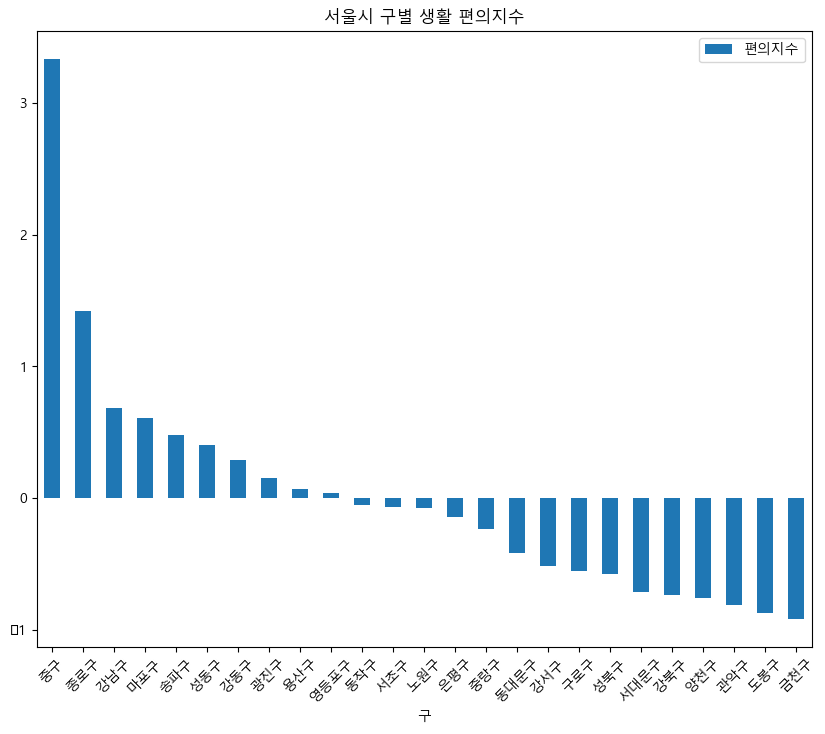

In [21]:
#박스플롯 시각화

plt.rcParams['font.family'] = 'Malgun Gothic'

df_rank.plot(
    x="구",
    y="편의지수",
    kind="bar",   # ← barh → bar
    figsize=(10,8)
)

plt.title("서울시 구별 생활 편의지수")
plt.xticks(rotation=45)  # 글자 겹침 방지
plt.show()

array([[<Axes: title={'center': '병원_천명당'}>,
        <Axes: title={'center': '약국_천명당'}>],
       [<Axes: title={'center': '음식점_천명당'}>,
        <Axes: title={'center': '상비약_천명당'}>]], dtype=object)

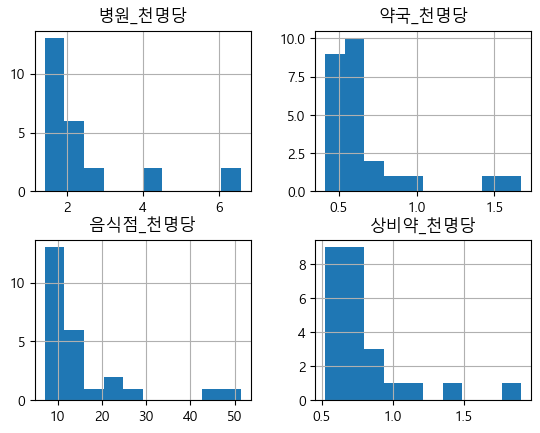

In [22]:
#히스토그램
'''
x축-> 천명당 시설이 몇개 있는가
y축-> 해당 구간에 속하는 구 갯수


히스토그램 분석 결과, 모든 시설은 인구 대비 시설 밀도 기준에서 낮은 값 구간에 다수의 자치구가 집중되어 있으며,
일부 자치구에서 높은 값을 보이는 오른쪽 치우친 분포를 나타낸다.

이는 대부분의 자치구에서 시설 밀도가 유사한 수준을 보이는 반면,
일부 자치구에서 상대적으로 높은 시설 밀도가 나타나 전체 분포에 영향을 미치고 있음을 의미한다.
'''



df[["병원_천명당","약국_천명당","음식점_천명당","상비약_천명당"]].hist()


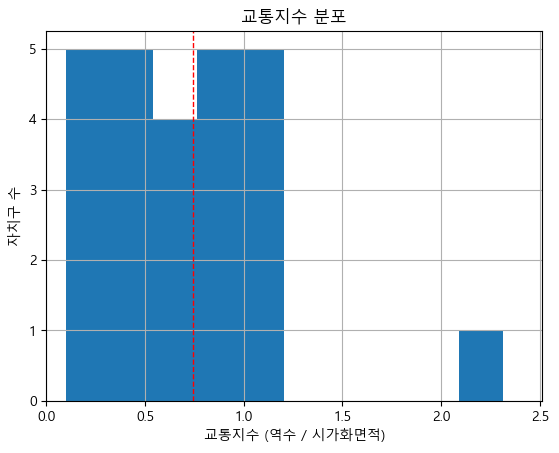

In [23]:
'''
x축- 단위면적당 지하철 역 수


교통지수 분포를 확인한 결과, 대부분의 자치구는 낮은 값 구간에 집중되어 있으며,
일부 자치구에서 높은 값을 보이는 우측으로 치우친 분포를 나타낸다.
이는 지하철 접근성이 특정 중심 자치구에 집중되어 있음을 의미한다.

'''

df["교통지수"].hist(bins=10)

plt.title("교통지수 분포")
plt.xlabel("교통지수 (역수 / 시가화면적)")
plt.ylabel("자치구 수")

# 평균선
plt.axvline(df["교통지수"].mean(), color='red', linestyle='dashed', linewidth=1)

plt.xlim(0, df["교통지수"].max() + 0.2)

plt.show()

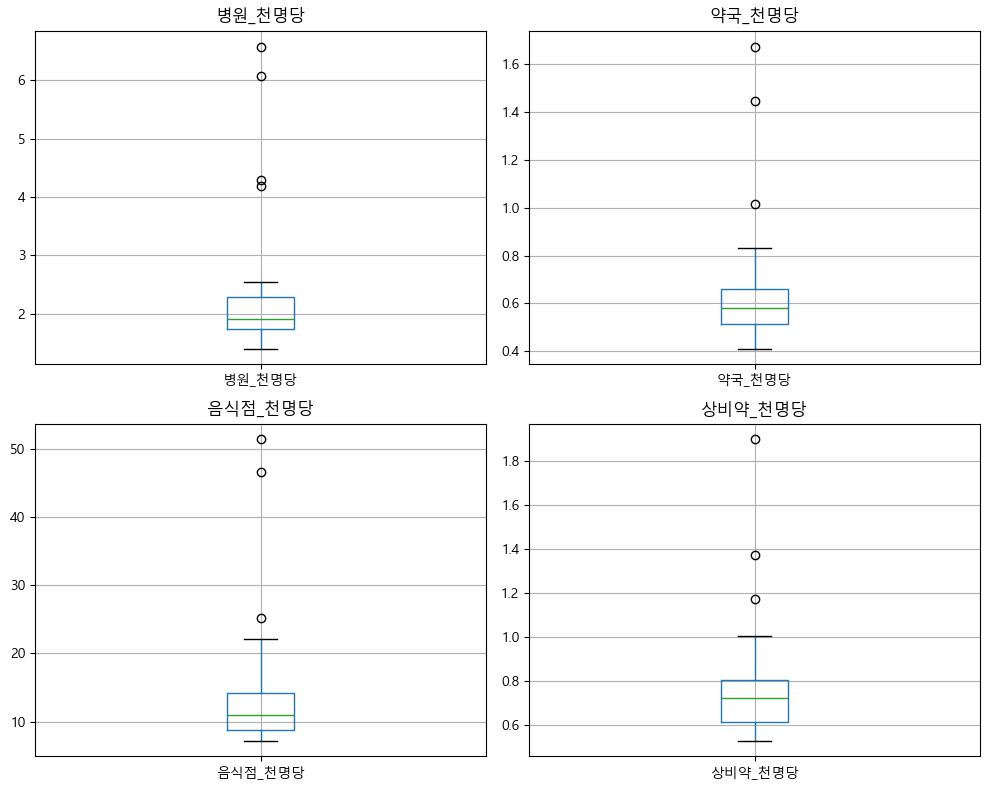

In [24]:
#박스플롯

'''
X축: 시설 종류
Y축: 인구 1000명당 시설 수 (시설 밀도 값)


박스플롯 분석 결과, 일부 자치구에서 시설 밀도가 다른 지역에 비해 크게 높은 이상치가 존재하는 것으로 나타났다.
이는 특정 상업 중심 지역에 시설이 집중되어 있음을 의미한다.
이러한 이상치는 데이터 오류가 아닌 실제 지역 특성을 반영하는 값으로 판단되며, 본 분석에서는 이를 제거하지 않고 포함하였다.
'''
fig, axes = plt.subplots(2, 2, figsize=(10,8))

cols = ["병원_천명당", "약국_천명당", "음식점_천명당", "상비약_천명당"]

for i, col in enumerate(cols):
    ax = axes[i//2, i%2]
    df.boxplot(column=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

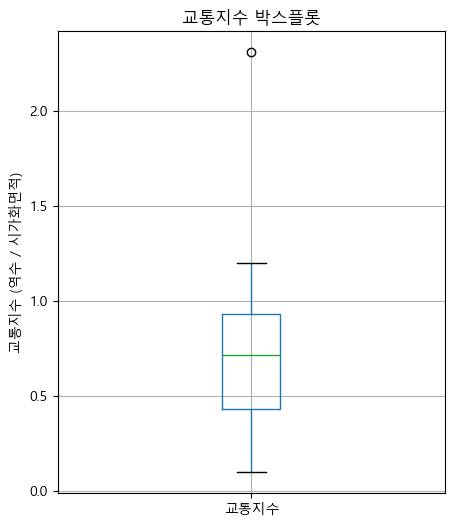

In [25]:
'''
교통지수에 대한 박스플롯 분석 결과, 일부 자치구에서 높은 값이 나타나는 이상치가 확인되었다.
이는 지하철 접근성이 특정 중심 자치구에 집중되어 있음을 의미한다.
다만 교통지수는 면적 기준 지표로, 인구 기준 시설 지표와 직접적인 비교에는 한계가 있다.
'''

plt.figure(figsize=(5,6))
df.boxplot(column="교통지수")

plt.title("교통지수 박스플롯")
plt.ylabel("교통지수 (역수 / 시가화면적)")

plt.show()

In [26]:
#변동계수 cv

'''
CV = 표준편차 / 평균으로 평균 대비 얼마나 퍼져 있는가를 나타낸다.
상대적 변동성 (지역 간 격차)를 의미

음식점   0.74  → 가장 큼
병원     0.55
약국     0.44
상비약   0.40

변동계수(CV) 분석 결과, 음식점의 CV가 0.74로 가장 높게 나타나
자치구 간 분포 격차가 가장 큰 시설임을 확인하였다.

반면 약국과 상비약 판매업소는 상대적으로 낮은 CV 값을 보여
지역 간 분포가 비교적 균등한 것으로 나타났다.

본 분석에서는 자치구 간 인구 규모 차이를 고려하기 위해
시설 수가 아닌 인구 1000명당 시설 수를 기준으로 변동계수를 산출하였다.


추가적으로 교통지수 또한 높은 CV 값을 보이며,
지하철 접근성이 특정 자치구에 집중되어 있음을 확인하였다.

'''

for col in ["병원_천명당","약국_천명당","음식점_천명당","상비약_천명당"]:
    cv = df[col].std() / df[col].mean()
    print(col, cv)



cv_transport = df["교통지수"].std() / df["교통지수"].mean()
print("교통지수", cv_transport)

병원_천명당 0.5543542580311275
약국_천명당 0.4392179289809152
음식점_천명당 0.7440271847430621
상비약_천명당 0.37876380196241255
교통지수 0.6188167565076228


In [27]:
#편의 지수에 어떤 시설 지표가 가장 크게 반영되었는가

'''
편의지수와 각 변수 간 상관분석 결과, 교통지수가 r=0.952로 가장 높은 양의 상관을 보였으며,
상비약, 약국, 음식점, 병원 등 시설 지표 또한 0.75~0.86 수준의 높은 양의 상관을 나타냈다.
이는 해당 변수들이 편의지수 산출식에 직접 포함된 구조적 결과로 해석된다.

특히 교통지수는 상대적으로 높은 가중치가 부여된 변수로,
편의지수 변동에 가장 큰 영향을 미치는 요인으로 나타났다.

반면 인구 구조 변수(고령화율, 청년비율, 성비)와 인구 규모는
편의지수와 낮은 상관관계를 보여,
편의 수준이 인구 구성보다는 시설 공급과 교통 접근성에 의해 설명됨을 뜻한다.

'''
cols = [
    "편의지수",
    "병원_천명당",
    "약국_천명당",
    "음식점_천명당",
    "상비약_천명당",
    "교통지수",
    "고령화율",
    "청년비율",
    "성비",
    "인구"
]

numeric_df = df.select_dtypes(include="number")


numeric_df[cols].corr()["편의지수"].sort_values(ascending=False)



편의지수       1.000000
교통지수       0.952316
상비약_천명당    0.857695
약국_천명당     0.856102
음식점_천명당    0.849575
병원_천명당     0.748583
청년비율       0.148854
고령화율      -0.133553
성비        -0.302104
인구        -0.323524
Name: 편의지수, dtype: float64

C:\Users\Jiho\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\Users\Jiho\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


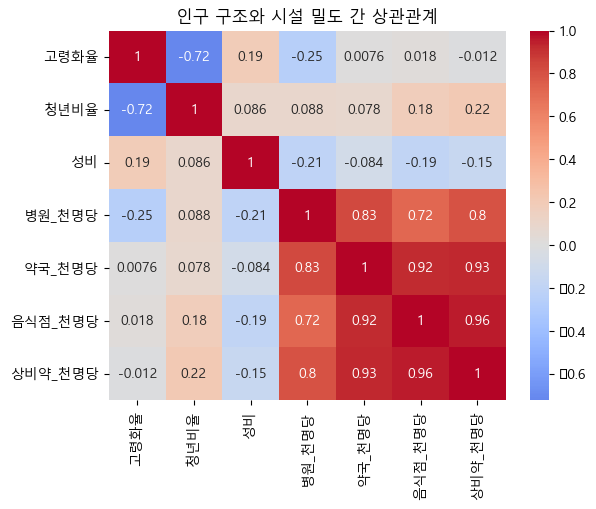

In [28]:
#히트맵


'''
 인구 구조 vs 시설
고령화율, 청년비율, 성비와 시설_천명당 간 상관관계는 전반적으로 낮음
→ 인구 구조가 시설 분포를 직접적으로 설명하지 못함

시설 간 관계
병원, 약국, 음식점, 상비약_천명당 변수 간 높은 양의 상관관계 존재
→ 특정 자치구에 다양한 시설이 함께 집중되는 경향

결론:
시설 분포는 인구 규모나 인구 구조보다는 지역의 상업적/중심지 특성에 의해 결정되는 경향이 큼

'''
cols = [
    "고령화율",
    "청년비율",
    "성비",
    "병원_천명당",
    "약국_천명당",
    "음식점_천명당",
    "상비약_천명당"
]

corr = df[cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("인구 구조와 시설 밀도 간 상관관계")
plt.show()

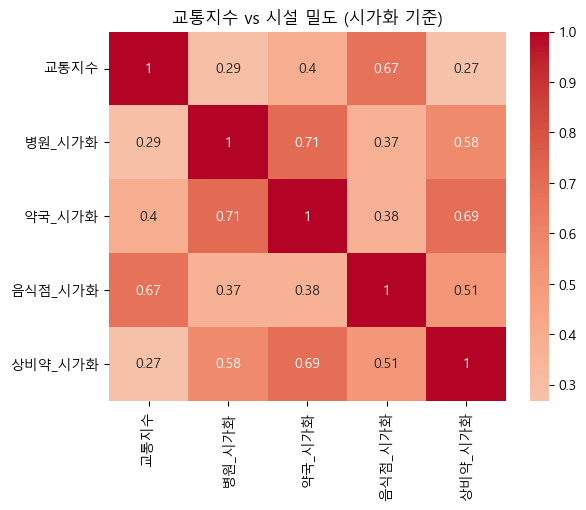

In [29]:
'''
교통지수와 시설 밀도 간 상관분석 결과, 음식점과의 상관계수(0.67)가 가장 높게 나타나
지하철 접근성이 높은 지역일수록 음식점이 밀집되는 경향이 확인되었다.

반면 병원(0.29), 약국(0.40), 상비약(0.27)은 상대적으로 낮은 상관을 보여
의료 및 생활 편의시설은 교통 외의 요인에 의해 분포가 결정되는 것으로 해석된다.

또한 시설 간 상관관계를 보면 병원과 약국(0.71), 약국과 상비약(0.69) 간 높은 양의 상관이 나타나,
의료 관련 시설은 동일 지역에 함께 집중되는 경향이 확인되었다.
'''


cols2 = [
    "교통지수",
    "병원_시가화",
    "약국_시가화",
    "음식점_시가화",
    "상비약_시가화"
]

corr2 = df[cols2].corr()

sns.heatmap(corr2, annot=True, cmap="coolwarm", center=0)
plt.title("교통지수 vs 시설 밀도 (시가화 기준)")
plt.show()

In [30]:
#편의지수 상위 5개구

top = df.nlargest(5, "편의지수")
print(top)

      구      인구      고령화율      청년비율        성비   병원수  약국수   음식점수  상비약판매업소수  \
1    중구  117762  0.233310  0.702502  0.924373   714  197   6053       224   
0   종로구  136817  0.226653  0.706535  0.918435   572  198   6378       188   
22  강남구  554165  0.174255  0.710705  0.913890  3644  563  12228       650   
13  마포구  356966  0.174695  0.740409  0.865806   897  228   7848       359   
23  송파구  650071  0.187138  0.706474  0.918225  1487  422   7031       397   

    시가화면적  ...     음식점_시가화    상비약_시가화  병원_천명당_z  약국_천명당_z  음식점_천명당_z  \
1    9.95  ...  608.341709  22.512563  2.661302  3.350042   3.206695   
0   12.77  ...  499.451840  14.722005  1.275060  2.590959   2.783207   
22  26.17  ...  467.252579  24.837600  3.038798  1.140430   0.609547   
13  14.33  ...  547.662247  25.052338  0.046704 -0.128401   0.602434   
23  23.30  ...  301.759657  17.038627 -0.119295 -0.093274  -0.386464   

    상비약_천명당_z      시설지수      교통지수    교통지수_z      편의지수  
1    3.637525  3.213891  2.311558  3.414620  3.3

In [31]:
#편의지수 하위 5개구

bottom = df.nsmallest(5, "편의지수")
print(bottom)

      구      인구      고령화율      청년비율        성비  병원수  약국수  음식점수  상비약판매업소수  \
17  금천구  222712  0.226162  0.712274  1.008187  418  147  3101       164   
9   도봉구  299065  0.265374  0.662953  0.930859  419  123  2229       181   
20  관악구  478468  0.194778  0.755430  1.010159  797  240  4705       363   
14  양천구  423666  0.202169  0.690591  0.947352  763  200  3018       222   
8   강북구  278786  0.269572  0.667734  0.924746  533  167  3247       209   

    시가화면적  ...     음식점_시가화    상비약_시가화  병원_천명당_z  약국_천명당_z  음식점_천명당_z  \
17  10.12  ...  306.422925  16.205534 -0.421669 -0.056660  -0.111290   
9    9.84  ...  226.524390  18.394309 -0.772098 -0.893395  -0.684164   
20  15.72  ...  299.300254  23.091603 -0.577158 -0.589600  -0.473429   
14  13.43  ...  224.720774  16.530156 -0.477578 -0.688929  -0.713354   
8   11.25  ...  288.622222  18.577778 -0.395895 -0.261903  -0.312875   

    상비약_천명당_z      시설지수      교통지수    교통지수_z      편의지수  
17  -0.209881 -0.199875  0.098814 -1.400939 -0.920514  
9   

In [32]:
#맵 시각화
#1. 전체 구별 편의지수 시각화 


'''
최종적으로 산출한 생활 편의지수를 서울시 자치구 지도에 시각화하였다.
지도에서 색이 진한 지역일수록 시설 공급 수준(인구 1000명당 병원, 약국, 음식점, 상비약)과
지하철 접근성(면적 대비 역 수)을 종합한 생활 편의지수가 높은 지역을 의미한다.

시각화 결과, 중구·종로구·강남구 등 중심 자치구에서 높은 편의지수가 나타났으며,
이는 해당 지역이 시설 밀도와 지하철 접근성이 모두 높은 지역임을 의미한다.

반면 강북구 양천구 관악구 등 일부 자치구는 상대적으로 낮은 값을 보였으며,
이는 시설 공급 수준과 교통 접근성이 모두 낮거나 상대적으로 부족한 지역임을 의미한다.

이를 통해 생활 편의 요소는 서울시 전역에 균등하게 분포하기보다는
교통 접근성이 높은 중심 지역에 집중되는 경향이 있음을 확인할 수 있다.
'''
with open("skorea_municipalities_geo_simple.json", encoding="utf-8") as f:
    geo_data = json.load(f)

m = folium.Map(location=[37.55, 126.98], zoom_start=11)

folium.Choropleth(
    geo_data=geo_data,
    data=df,
    columns=["구", "편의지수"],
    key_on="feature.properties.name",
    fill_color="YlGnBu",
    legend_name="생활 편의지수"
).add_to(m)

m

In [33]:
# ============================================================
# 2. 시설지수 지도 시각화
# ============================================================
# 목적:
# - 종합 편의지수는 시설지수와 교통지수를 결합한 값이다.
# - 이 지도는 그중 교통 접근성을 제외하고,
#   인구 1,000명당 생활 편의시설 공급 수준만 따로 확인하기 위한 시각화이다.


m_facility = folium.Map(
    location=[37.55, 126.98],
    zoom_start=11
)

folium.Choropleth(
    geo_data=geo_data,
    data=df,
    columns=["구", "시설지수"],
    key_on="feature.properties.name",
    fill_color="YlGnBu",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="시설지수"
).add_to(m_facility)

m_facility

In [34]:
# ============================================================
# 3. 교통지수 지도 시각화
# ============================================================
# 목적:
# - 교통지수는 시가화면적 대비 지하철역 수로 계산한 접근성 지표이다.
# - 현재 종합 편의지수에서 교통지수는 주요 구성 요소로 사용되었으므로,
#   지역별 교통 접근성 차이를 별도로 확인하기 위해 시각화한다.
#
# 계산식:
# - 교통지수 = 역수 / 시가화면적


m_transport = folium.Map(
    location=[37.55, 126.98],
    zoom_start=11
)

folium.Choropleth(
    geo_data=geo_data,
    data=df,
    columns=["구", "교통지수"],
    key_on="feature.properties.name",
    fill_color="YlGnBu",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="교통지수"
).add_to(m_transport)

m_transport

In [35]:
# ============================================================
# 4. 음식점_천명당 지도 시각화
# ============================================================
# 목적:
# - 기존 변동계수(CV) 분석에서 음식점_천명당의 지역 간 격차가 가장 크게 나타났다.
# - 따라서 생활 편의시설 중 자치구별 분포 차이가 가장 큰 개별 시설 유형을
#   공간적으로 확인하기 위해 시각화한다.
#
# 근거:
# - 음식점_천명당 CV = 약 0.744
# - 병원_천명당, 약국_천명당, 상비약_천명당보다 변동계수가 큼


m_restaurant = folium.Map(
    location=[37.55, 126.98],
    zoom_start=11
)

folium.Choropleth(
    geo_data=geo_data,
    data=df,
    columns=["구", "음식점_천명당"],
    key_on="feature.properties.name",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.3,
    legend_name="인구 1,000명당 음식점 수"
).add_to(m_restaurant)

m_restaurant

In [36]:
# ============================================================
# 지수별 자치구 순위표
# ============================================================


rank_cols = [
    "편의지수",
    "시설지수",
    "교통지수",
    "음식점_천명당"
]

rank_tables = {}

for col in rank_cols:
    rank_table = df[["구", col]].copy()
    
    # 값이 큰 자치구가 높은 순위가 되도록 내림차순 정렬
    rank_table = rank_table.sort_values(col, ascending=False).reset_index(drop=True)
    
    # 1위부터 순위 부여
    rank_table["순위"] = rank_table.index + 1
    
    # 보기 좋은 컬럼 순서로 정리
    rank_table = rank_table[["순위", "구", col]]
    
    # 소수점 자리 정리
    rank_table[col] = rank_table[col].round(3)
    
    rank_tables[col] = rank_table

# 종합 편의지수 순위
display(rank_tables["편의지수"])

# 시설지수 순위
display(rank_tables["시설지수"])

# 교통지수 순위
display(rank_tables["교통지수"])

# 음식점_천명당 순위
display(rank_tables["음식점_천명당"])


,순위,구,편의지수
0,1,중구,3.334
1,2,종로구,1.419
2,3,강남구,0.680
3,4,마포구,0.608
4,5,송파구,0.477
5,6,성동구,0.406
6,7,강동구,0.285
7,8,광진구,0.153
8,9,용산구,0.067
9,10,영등포구,0.038


,순위,구,시설지수
0,1,중구,3.214
1,2,종로구,2.136
2,3,강남구,1.505
3,4,서초구,0.316
4,5,마포구,0.300
5,6,영등포구,0.225
6,7,용산구,0.150
7,8,동대문구,-0.036
8,9,금천구,-0.200
9,10,성동구,-0.226


,순위,구,교통지수
0,1,중구,2.312
1,2,송파구,1.202
2,3,종로구,1.175
3,4,성동구,1.123
4,5,마포구,1.117
5,6,강동구,1.099
6,7,광진구,0.932
7,8,노원구,0.892
8,9,동작구,0.849
9,10,은평구,0.818


,순위,구,음식점_천명당
0,1,중구,51.400
1,2,종로구,46.617
2,3,용산구,25.224
3,4,강남구,22.066
4,5,마포구,21.985
5,6,영등포구,17.994
6,7,성동구,14.221
7,8,금천구,13.924
8,9,서초구,13.325
9,10,광진구,12.868


# 지수별 순위 결과

지수별 순위표를 비교한 결과, 종합 편의지수 상위 지역은 대체로 시설지수와 교통지수가 모두 높은 지역으로 나타났다. 
중구는 시설지수, 교통지수, 음식점_천명당 지표에서 모두 1위를 기록하여 종합 편의지수 역시 가장 높게 나타났으며, 
종로구 또한 시설지수 2위와 교통지수 3위로 두 요소가 모두 높은 지역이었다.

반면 일부 자치구는 시설지수와 교통지수 간 순위 차이가 크게 나타났다. 송파구는 시설지수 순위가 13위였으나 교통지수 2위로 나타나 종합 편의지수 5위를 기록하였고, 
성동구와 강동구 역시 시설지수에 비해 교통지수가 높아 종합 순위가 상승하였다. 이는 교통 접근성이 종합 편의지수에 중요한 영향을 미쳤음을 보여준다.

반대로 서초구, 영등포구, 용산구는 시설지수 순위에 비해 교통지수 순위가 낮아 종합 편의지수 순위가 상대적으로 낮게 나타났다. 
특히 금천구는 시설지수 9위였음에도 교통지수가 25위로 가장 낮아 종합 편의지수 역시 최하위로 나타났다.

음식점_천명당 지표는 생활 편의시설 중 자치구 간 변동계수가 가장 큰 항목으로, 개별 시설의 지역 격차를 확인하기 위한 보조 지표로 활용하였다. 
중구와 종로구는 음식점_천명당에서도 각각 1위와 2위를 기록하여 시설지수 상위권 형성에 영향을 준 것으로 볼 수 있다.


'''
# 결론

본 연구는 서울시 자치구별 인구 구조(연령, 성별), 생활 편의 시설 분포,
그리고 대중교통 접근성(지하철·버스) 간의 관계를 정량적으로 분석하는 것을 목적으로 수행되었다.

이를 위해 병원, 약국, 음식점, 상비약 판매업소를 대상으로 인구 1000명당 시설 수를 산출하여 지역 간 비교가 가능하도록 정규화하였으며, 지하철 역 밀도와 버스정류장 밀도를 교통 접근성 변수로 추가 정의하였다.

상관분석 결과를 바탕으로, 시설 밀도와 유의한 관계가 확인된 지하철 밀도를 최종 교통지수로 활용하였다.이후 분포 분석, 변동계수(CV), 상관관계 분석(Pearson, Spearman)을 통해 데이터의 구조를 검증하였다.

분석 결과는 다음과 같다.


### 1. 시설 분포의 특징
시설 간 상관관계가 높게 나타나, 특정 자치구에 다양한 시설이 함께 집중되는 경향이 확인되었다.
변동계수 분석 결과, 특히 음식점의 지역 간 격차가 크게 나타나 상업시설이 일부 지역에 집중되어 있음을 확인하였다.



### 2. 인구 구조와 시설 분포 관계
Pearson 상관분석에서는 유의한 관계가 나타나지 않아, 인구 구조가 시설 분포를 직접적으로 설명하지 못하는 것으로 나타났다.
그러나 Spearman 분석에서는 일부 변수(청년비율–음식점, 고령화율–병원) 간 약한 순위 기반 관계가 확인되었다.

→ 이는 인구 구조가 시설 분포에 강한 영향을 주기보다는
일부 경향성 수준에서만 영향을 미칠 수 있음을 의미한다.



### 3. 교통 접근성과 시설 분포
지하철 및 버스 접근성과 시설 밀도 간 상관분석 결과, 지하철 밀도는 음식점·약국·병원과 일부 유의한 
양의 관계가 확인되었다.

특히 음식점은 Pearson과 Spearman 상관분석 모두에서 가장 일관된 양의 상관관계를 보여, 지하철 접근성이 
높은 지역일수록 상업시설이 밀집되는 경향이 확인되었다.

반면 버스정류장 밀도는 시설 밀도와 유의한 관계가 나타나지 않았다.
따라서 최종 편의지수 구성에서는 제외하였다.

### 4. 생활 편의지수 기반 지역 비교
시설 공급 수준(천명당 시설 수)과 지하철 접근성을 결합하여 생활 편의지수를 산출하였다.
초기에는 버스정류장 밀도 역시 교통 변수 후보로 포함하여 분석하였으나,
상관분석에서 시설 밀도와 유의한 관계가 확인되지 않아 최종 편의지수 구성에서는 제외하였다.

이 과정에서 시설은 상대적 중요도를 구분할 명확한 근거가 없어 동일 가중치로 통합하였으며,
지하철 기반 교통지수는 상관분석 결과를 반영하여 상대적으로 높은 비중으로 포함하였다.

그 결과, 중구·종로구·강남구 등 중심 지역에서 높은 편의지수가 나타났으며,
금천구·도봉구·관악구·양천구·강북구 등 일부 지역은 상대적으로 낮은 값을 보였다.

이는 생활 편의 요소가 균등하게 분포하기보다, 시설 공급 수준과 지하철 접근성이 함께 높은 일부 중심 지역에서 높은 편의지수가 나타나는 경향을 보여준다.



### 5. 세부 비교
추가적으로 시설지수, 교통지수, 음식점_천명당 지표를 각각 지도와 순위표로 시각화하여
종합 편의지수의 구성 요인을 분해해 확인하였다.

그 결과, 중구와 종로구는 시설지수와 교통지수가 모두 상위권으로 나타나
종합 편의지수 역시 높게 산출되었다. 특히 중구는 시설지수, 교통지수,
음식점_천명당 지표에서 모두 1위를 기록하여 생활 편의 요소가 가장 집중된 지역으로 확인되었다.

반면 일부 자치구는 시설지수와 교통지수 간 순위 차이가 크게 나타났다.
송파구는 시설지수 13위였으나 교통지수 2위로 나타나 종합 편의지수 5위를 기록하였고,
성동구와 강동구 역시 시설지수에 비해 교통지수 순위가 높아 종합 순위가 상승하였다.
이를 통해 종합 편의지수가 높은 지역이 반드시 시설 공급 수준만 높은 지역은 아니며,
교통지수와의 차이에 따라 순위가 달라질 수 있음을 확인하였다.

반대로 금천구는 시설지수 9위였음에도 교통지수가 25위로 가장 낮아
종합 편의지수 역시 최하위로 나타났다.
이는 시설지수와 교통지수 중 어느 한쪽만으로는 종합 편의지수 순위를 설명하기 어렵고,
두 지표를 함께 비교할 필요가 있음을 보여준다.

음식점_천명당 지표는 생활 편의시설 중 변동계수가 가장 큰 항목으로,
지역 간 시설 분포 격차를 보여주는 보조 지표로 활용하였다.
중구와 종로구는 음식점_천명당에서도 각각 1위와 2위를 기록하여
시설지수 상위권 형성에 영향을 준 것으로 나타났다.



### 최종 해석

본 분석에서는 시설 공급 수준과 지하철 접근성을 함께 반영하여 생활 편의지수를 구성하였다.
그 결과 중구·종로구·강남구 등 중심 지역에서 높은 편의지수가 나타났으며,
일부 외곽 지역에서는 상대적으로 낮은 값이 확인되었다.

세부 지표를 비교한 결과, 종합 편의지수 순위는 시설지수와 교통지수의 순위가 함께 반영되어 나타났다.
특히 송파구, 성동구, 강동구처럼 시설지수보다 교통지수 순위가 높은 지역은
종합 편의지수에서도 상대적으로 높은 순위를 보였다.
반대로 금천구처럼 시설지수에 비해 교통지수 순위가 낮은 지역은
종합 편의지수 순위가 크게 낮아지는 모습을 보였다.

또한 지하철 기반 교통지수와 시설 밀도 간 상관분석 결과, 음식점과의 상관이 가장 높게 나타났으며,
약국과 병원 역시 일부 분석에서 유의한 양의 관계가 확인되었다.

반면 버스정류장 밀도는 시설 밀도와 유의한 관계가 나타나지 않아 최종 편의지수 구성 변수에서는 제외하였다.

이는 지하철 접근성이 높은 지역에서 상업시설과 일부 생활 편의시설이 함께 밀집되는 경향이 있음을 보여준다.
다만 본 분석은 상관관계에 기반하므로, 교통 접근성이 상업시설 분포를 직접적으로 결정한다고 단정할 수는 없다.

음식점_천명당 지표는 생활 편의시설 중 지역 간 격차가 가장 크게 나타난 항목이었다.
따라서 음식점_천명당 지도와 순위표는 시설지수 내부에서 어떤 시설 유형이 지역 격차를 크게 만드는지
확인하기 위한 보조 자료로 활용할 수 있다.

종합하면, 서울시 생활 편의 요소는 모든 자치구에 균등하게 분포하기보다
시설 공급 수준과 지하철 접근성이 함께 높은 중심 지역에서 높게 나타나는 경향을 보였다.




### 한계 및 향후 연구 방향

본 연구는 시설의 “수”와 지하철 역 수만을 기반으로 분석을 수행하였기 때문에 다음과 같은 한계가 존재한다.

- 시설의 규모 및 질(병원 규모, 음식점 종류 등) 미반영
- 실제 이용량 또는 유동 인구 데이터 부재
- 거리 기반 접근성(이동 시간, 실제 접근성) 미반영
- 편의지수 가중치 설정에 따라 최종 순위가 달라질 수 있음

따라서 향후에는 다음과 같은 분석이 필요하다.

- 유동 인구 데이터를 활용한 수요 기반 분석
- 거리 기반 접근성 분석(GIS 활용)
- 교통 지표 정교화(환승 정보, 승하차 인원, 이동 시간 등 실제 이용 기반 변수 포함)
- 시설 규모와 실제 이용 가능성을 반영한 지표 개선
- 명확한 분류 기준이 확보될 경우 시설 유형 세분화 분석 검토
